In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn import metrics
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl

### Preprocessing

In [2]:
X_ = pd.read_csv('..\\data\\sampled_preprocessed_X.csv')
y = pd.read_csv('..\\data\\sampled_preprocessed_y.csv')

In [3]:
X_.columns.values.tolist()

['Src Port',
 'Dst Port',
 'Protocol',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd By

#### Feature selection

In [4]:
flow_features = ['Flow Byts/s', 'Flow Pkts/s', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts']

pkt_len_and_timing_features = ['Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min']

flag_and_header_features = ['Fwd Header Len', 'Bwd Header Len', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt']

activity_features = ['Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

In [5]:
features = flow_features + pkt_len_and_timing_features + flag_and_header_features + activity_features

In [6]:
X = X_[features]

In [7]:
X.shape

(200, 41)

### Model

#### Dimensionality reduction

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
pca.explained_variance_ratio_

array([0.31749163, 0.1492049 , 0.1176432 ])

In [18]:
pca_data = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "PCA3": X_pca[:, 2],
    "Label": y['Label']
})

# Apply Seaborn style
sns.set(style="whitegrid")
%matplotlib notebook
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Map labels to colors and markers for legend
label_mapping = {0: ('Benign', 'green', 'o'), 1: ('DDOS', 'red', 'x')}  # Update with your label names
for label, (label_name, color, marker) in label_mapping.items():
    subset = pca_data[pca_data['Label'] == label]
    ax.scatter(
        subset['PCA1'], 
        subset['PCA2'], 
        subset['PCA3'], 
        color=color, label=label_name, marker=marker, s=50, alpha=0.8
    )

# Add labels and title
ax.set_title("3D Scatter Plot of PCA Components", fontsize=14)
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")

# Add a legend
ax.legend(title="Type", loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()
# mpl.use('Qt5Agg')

plt.show()

<IPython.core.display.Javascript object>

C:\Users\User\AppData\Local\Temp\ipykernel_8620\200142090.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


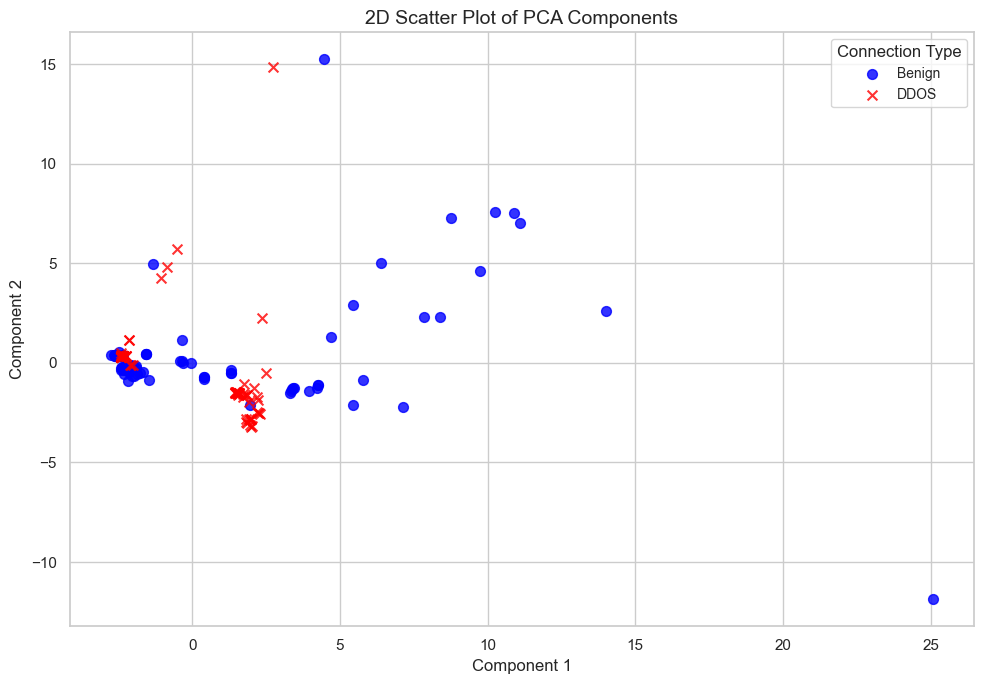

In [21]:
%matplotlib inline

sns.set(style="whitegrid")

# Map labels to colors and markers for the legend
label_mapping = {0: ('Benign', 'blue', 'o'), 1: ('DDOS', 'red', 'x')}

# Create a 2D scatter plot
plt.figure(figsize=(10, 7))

for label, (label_name, color, marker) in label_mapping.items():
    subset = pca_data[pca_data['Label'] == label]
    plt.scatter(
        subset['PCA1'], 
        subset['PCA2'], 
        color=color, label=label_name, marker=marker, s=50, alpha=0.8
    )

# Add labels and title
plt.title("2D Scatter Plot of PCA Components", fontsize=14)
plt.xlabel("Component 1")
plt.ylabel("Component 2")

# Add a legend
plt.legend(title="Connection Type", fontsize=10, loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()


### Clustering

#### K-Distance Graph

In [106]:
from sklearn.neighbors import NearestNeighbors
min_pts = 10 # Minimum number of points to define a cluster

In [107]:
# Method ref: https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd

neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

finding the optimal value for epsilon

In [108]:
distances = np.sort(distances, axis=0)
distances

array([[0.00000000e+00, 2.08124687e-06, 2.84212974e-06, ...,
        2.38416649e-05, 2.60971857e-05, 3.63587826e-05],
       [0.00000000e+00, 2.08124687e-06, 4.92333892e-06, ...,
        2.44113261e-05, 2.71773829e-05, 3.79503654e-05],
       [0.00000000e+00, 2.82675364e-06, 4.92333892e-06, ...,
        2.59011116e-05, 2.77467981e-05, 3.82018513e-05],
       ...,
       [0.00000000e+00, 1.06503731e+01, 1.09090394e+01, ...,
        1.19982749e+01, 1.20970755e+01, 1.26444258e+01],
       [0.00000000e+00, 2.00829843e+01, 2.15868930e+01, ...,
        2.44113220e+01, 2.44175710e+01, 2.44315549e+01],
       [0.00000000e+00, 2.88617355e+01, 3.11255669e+01, ...,
        3.16781859e+01, 3.17170593e+01, 3.17362209e+01]])

In [109]:
distances = distances[:,1]
distances

array([2.08124687e-06, 2.08124687e-06, 2.82675364e-06, 2.82675364e-06,
       2.84212974e-06, 3.33869330e-06, 3.33869330e-06, 4.92625991e-06,
       4.92625991e-06, 5.04811046e-06, 5.04811046e-06, 8.45282162e-06,
       9.32231882e-06, 1.21218605e-05, 1.25312246e-05, 1.67794428e-05,
       2.25928939e-05, 2.54179049e-05, 4.30545820e-05, 4.30545820e-05,
       4.83906586e-05, 5.40728098e-05, 5.40728098e-05, 6.04554761e-05,
       6.04554761e-05, 6.25239908e-05, 6.25239908e-05, 7.40768960e-05,
       9.79031044e-05, 1.00367735e-04, 1.06117122e-04, 1.17403160e-04,
       1.17403160e-04, 1.61001002e-04, 1.63074287e-04, 1.70987055e-04,
       1.70987055e-04, 1.73620304e-04, 2.45014898e-04, 2.47951074e-04,
       2.47951074e-04, 2.55113727e-04, 2.55113727e-04, 3.77547994e-04,
       4.95160418e-04, 4.95160418e-04, 4.98854672e-04, 5.84441320e-04,
       5.84441320e-04, 6.89713108e-04, 6.91544999e-04, 6.91544999e-04,
       8.26004814e-04, 8.26004814e-04, 9.10107895e-04, 9.10107895e-04,
      

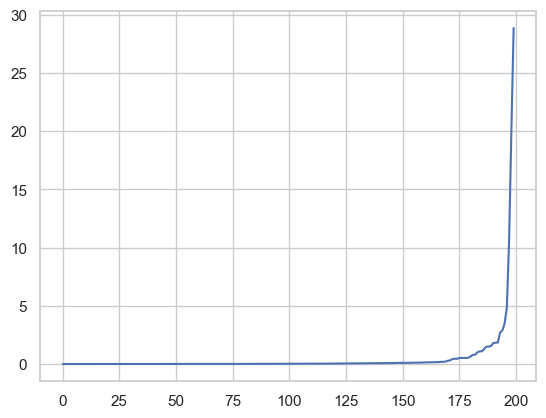

In [110]:
plt.plot(distances)
plt.show()

In [119]:
# According to the graph, the optimal value for epsilon is around 185
epsilon = 1 # TODO: Update with the optimal value when the entire dataset is used

In [116]:
dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
dbscan_labels = dbscan.fit_predict(X_pca)

In [117]:
dbscan_labels

array([ 0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  1, -1,  1,  0,  0,  0,
        1,  0,  1,  0,  0,  0,  0,  1, -1,  0,  0,  1,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0, -1,  0,  1,  0, -1,  0,
       -1, -1,  1,  1,  1,  0,  1,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1,
        1,  0,  0,  0,  0,  0,  1,  1,  1,  1,  0,  1,  0,  0,  0,  0,  0,
        0, -1,  0,  1,  0,  0,  0,  1,  0, -1,  0,  0, -1,  0,  1,  0, -1,
        0,  1,  1, -1, -1, -1, -1,  0,  0,  0, -1,  0,  0,  0,  1,  1, -1,
        1,  0, -1,  0,  0,  0, -1,  0,  0,  1,  0, -1,  0,  0, -1,  0,  1,
       -1,  1,  1, -1,  0, -1,  0, -1, -1,  0,  0, -1, -1,  0, -1,  0, -1,
        0,  0,  0,  0,  0,  0,  0,  1,  0,  1,  1,  0,  1,  0, -1, -1, -1,
        0, -1,  0,  1,  0,  0,  1,  1,  1, -1,  0,  0, -1, -1,  1, -1, -1,
        0,  0,  0,  1, -1,  0, -1,  0,  0,  0,  0,  0,  0])

#### Visualizing the clusters

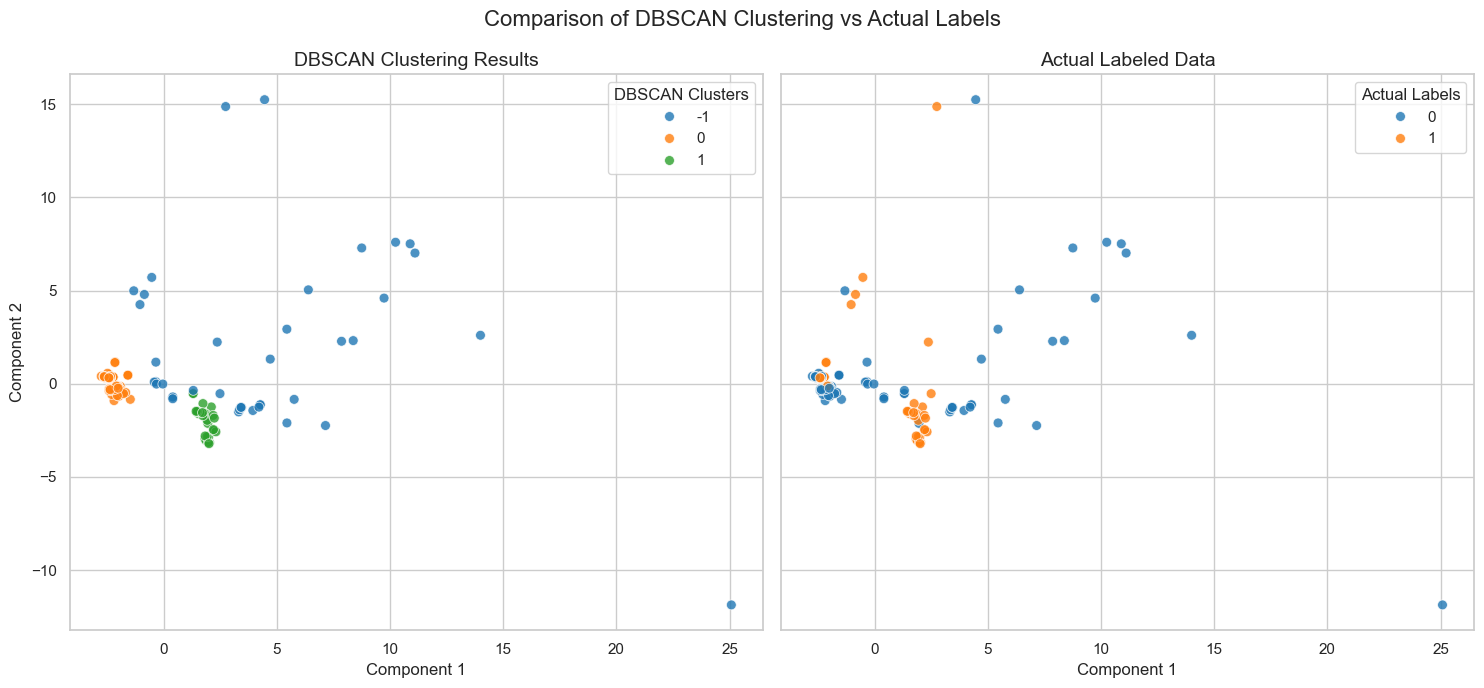

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# DBSCAN cluster labels and actual labels
pca_data = pd.DataFrame({
    "Component 1": X_pca[:, 0],
    "Component 2": X_pca[:, 1],
    "DBSCAN Cluster": dbscan_labels,  
    "Actual Label": y['Label']   
})

# Seaborn style
sns.set(style="whitegrid")

# figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

# Left plot: DBSCAN results
sns.scatterplot(
    data=pca_data,
    x='Component 1',
    y='Component 2',
    hue='DBSCAN Cluster',
    palette='tab10',
    ax=axes[0],
    s=50,
    alpha=0.8
)
axes[0].set_title("DBSCAN Clustering Results", fontsize=14)
axes[0].legend(title="DBSCAN Clusters")

# Right plot: Actual labels
sns.scatterplot(
    data=pca_data,
    x='Component 1',
    y='Component 2',
    hue='Actual Label',
    palette='tab10',
    ax=axes[1],
    s=50,
    alpha=0.8
)
axes[1].set_title("Actual Labeled Data", fontsize=14)
axes[1].legend(title="Actual Labels")

# Overall layout adjustments
fig.suptitle("Comparison of DBSCAN Clustering vs Actual Labels", fontsize=16)
plt.tight_layout()
plt.show()
